In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy as sc
from scipy.stats import norm

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $x'$.
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $$T=\{5,15,20\}$$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

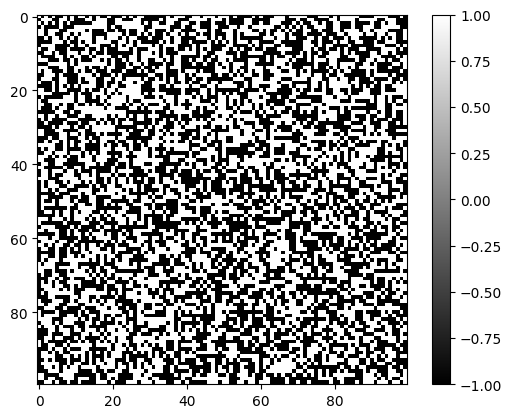

In [47]:
#Configuracion inicial

N = 100
H = np.linspace(-30,30,40)
red_i = np.zeros((N,N),float)
for i in range(N):
  for j in range(N):
    red_i[i,j]= np.random.choice([-1,1])

plt.imshow(red_i,cmap = "gray")
plt.colorbar()
plt.show()

In [51]:
#magnetizacion

def boltzmann(E,T,k_b = 1.0):
  return np.exp(-E/(k_b*T))

def mag(red,T,H,iter):
  N = red.shape[0]
  m_mu = 0
  ter = int(0.1*iter)
  sample = 0

  for i in range(iter):
    index_i = np.random.randint(0,N)
    index_j = np.random.randint(0,N)

    spin = red[index_i,index_j]
    E = 2*H*spin

    if E < 0:
      red[index_i,index_j] = -spin
    else:
      if np.random.random() < boltzmann(E,T):
        red[index_i,index_j] = -spin

    if i >= ter:
      sample += 1
      m_mu += np.sum(red)


  return m_mu/(sample*N*N)

def analitica(H,T):
  return np.tanh(H/T)

Para el caso analitico, la magnetizacion media se expresa como

$$\langle M \rangle = \tanh(\frac{\mu_0 H}{k_BT})$$

Entonces:

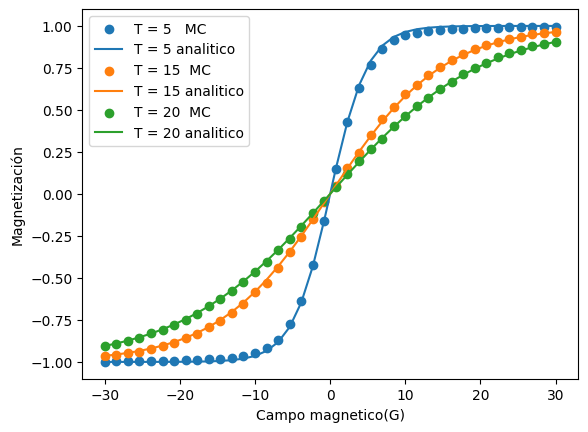

In [52]:
mag_list_1 = []
mag_list_2 = []
mag_list_3 = []

for i in H:
  mag_list_1.append(mag(red_i,5,i,100000))
  mag_list_2.append(mag(red_i,15,i,100000))
  mag_list_3.append(mag(red_i,20,i,100000))


plt.scatter(H,mag_list_1,label = "T = 5   MC")
plt.plot(H,analitica(H,5), label = "T = 5 analitico")

plt.scatter(H,mag_list_2,label = "T = 15  MC")
plt.plot(H,analitica(H,15),label = "T = 15 analitico")

plt.scatter(H,mag_list_3,label = "T = 20  MC")
plt.plot(H,analitica(H,20), label = "T = 20 analitico")

plt.xlabel("Campo magnetico(G)")
plt.ylabel("Magnetización")

plt.legend()
plt.show()